In [47]:
import torch
import torchvision
import torchvision.transforms as T
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# Загружаем предобученную модель Keypoint R-CNN
model = torchvision.models.detection.keypointrcnn_resnet50_fpn(pretrained=True)
model.eval()  # переводим в режим инференса

# Если доступен GPU, используем его
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
model.to(device)

KeypointRCNN(
  (transform): GeneralizedRCNNTransform(
      Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
      Resize(min_size=(640, 672, 704, 736, 768, 800), max_size=1333, mode='bilinear')
  )
  (backbone): BackboneWithFPN(
    (body): IntermediateLayerGetter(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): FrozenBatchNorm2d(64, eps=0.0)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): Bottleneck(
          (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn1): FrozenBatchNorm2d(64, eps=0.0)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): FrozenBatchNorm2d(64, eps=0.0)
          (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn3): FrozenBatchNorm2d(256, eps=0.

Список ключевых точек (в порядке, который выдаёт модель COCO)

In [48]:
keypoints = ['nose', 'left_eye', 'right_eye',
             'left_ear', 'right_ear', 'left_shoulder',
             'right_shoulder', 'left_elbow', 'right_elbow',
             'left_wrist', 'right_wrist', 'left_hip',
             'right_hip', 'left_knee', 'right_knee',
             'left_ankle', 'right_ankle']

Загрузка изображения и применение трансформаций

In [49]:
img_pil = Image.open('data/dspr_cv_u1_diploma_spr1_3_1.png').convert("RGB")

# Сохраняем оригинал в RGB для дальнейшего отображения
img_rgb = np.array(img_pil)

# Трансформация: PIL -> Tensor
transform = T.Compose([T.ToTensor()])
img_tensor = transform(img_pil).unsqueeze(0).to(device)  # добавляем batch dimension

Прогон изображения через модель

In [50]:
with torch.no_grad():
    outputs = model(img_tensor)

output = outputs[0]
boxes = output['boxes'].cpu()
labels = output['labels'].cpu()
scores = output['scores'].cpu()
keypoints_all = output['keypoints'].cpu()
keypoints_scores = output['keypoints_scores'].cpu()

print(f"Обнаружено людей: {len(boxes)}")
print("Уверенность каждой детекции:", scores.numpy())

Обнаружено людей: 2
Уверенность каждой детекции: [0.99974066 0.16493176]


Функция отрисовки ключевых точек (немного доработанная для коррекции цвета)

In [51]:
def draw_keypoints_per_person(img, all_keypoints, all_scores, confs,
                              keypoint_threshold=2, conf_threshold=0.9):
    """
    Рисует ключевые точки на изображении.
    img - изображение в формате BGR (как использует OpenCV)
    all_keypoints - тензор [N, 17, 3]
    all_scores - тензор [N, 17]
    confs - тензор [N] - уверенность детекции человека
    """
    cmap = plt.get_cmap("rainbow")
    img_copy = img.copy()
    # Генерируем цвета для каждого человека
    n_people = len(all_keypoints)
    if n_people == 0:
        return img_copy
    color_ids = np.linspace(0, 255, n_people, dtype=int).tolist()[::-1]

    for person_id in range(n_people):
        if confs[person_id] > conf_threshold:
            keypoints = all_keypoints[person_id]   # [17, 3]
            scores = all_scores[person_id]         # [17]
            for kp_idx, score in enumerate(scores):
                if score > keypoint_threshold:
                    # Координаты (x, y)
                    x, y = keypoints[kp_idx, :2].int().tolist()
                    # Цвет из RGB, конвертируем в BGR для OpenCV
                    color_rgb = np.array(cmap(color_ids[person_id])[:3]) * 255
                    color_bgr = (int(color_rgb[2]), int(color_rgb[1]), int(color_rgb[0]))
                    cv2.circle(img_copy, (x, y), 5, color_bgr, -1)
    return img_copy

Применяем функцию отрисовки ключевых точек.

Для этого преобразуем исходное RGB-изображение в BGR.

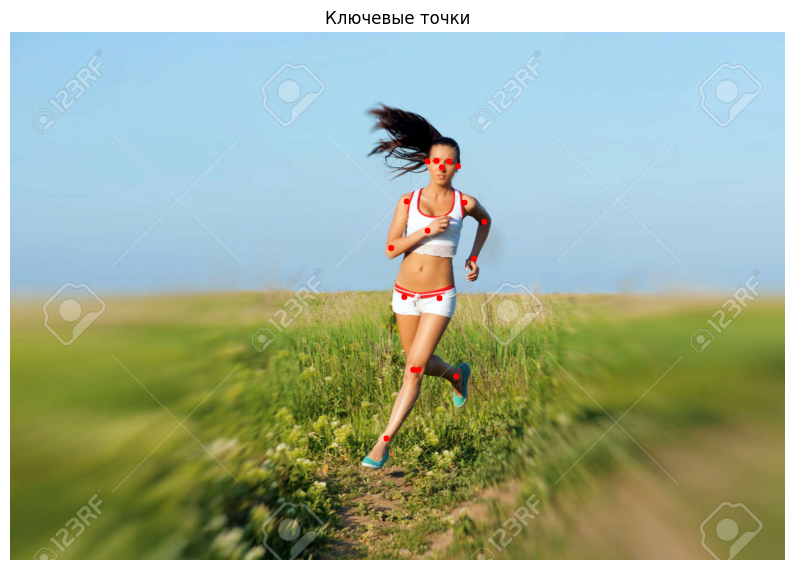

In [52]:
img_bgr = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2BGR)

img_with_keypoints = draw_keypoints_per_person(
    img_bgr,
    keypoints_all,
    keypoints_scores,
    scores,
    keypoint_threshold=2,
    conf_threshold=0.9
)

# Отобразим результат (для просмотра в Jupyter преобразуем BGR обратно в RGB)
plt.figure(figsize=(10, 8))
plt.imshow(cv2.cvtColor(img_with_keypoints, cv2.COLOR_BGR2RGB))
plt.title("Ключевые точки")
plt.axis('off')
plt.show()

Функция для построения списка конечностей (limbs)

In [53]:
def get_limbs_from_keypoints(keypoints):
    limbs = [
        [keypoints.index("right_eye"), keypoints.index("nose")],
        [keypoints.index("right_eye"), keypoints.index("right_ear")],
        [keypoints.index("left_eye"), keypoints.index("nose")],
        [keypoints.index("left_eye"), keypoints.index("left_ear")],
        [keypoints.index("right_shoulder"), keypoints.index("right_elbow")],
        [keypoints.index("right_elbow"), keypoints.index("right_wrist")],
        [keypoints.index("left_shoulder"), keypoints.index("left_elbow")],
        [keypoints.index("left_elbow"), keypoints.index("left_wrist")],
        [keypoints.index("right_hip"), keypoints.index("right_knee")],
        [keypoints.index("right_knee"), keypoints.index("right_ankle")],
        [keypoints.index("left_hip"), keypoints.index("left_knee")],
        [keypoints.index("left_knee"), keypoints.index("left_ankle")],
        [keypoints.index("right_shoulder"), keypoints.index("left_shoulder")],
        [keypoints.index("right_hip"), keypoints.index("left_hip")],
        [keypoints.index("right_shoulder"), keypoints.index("right_hip")],
        [keypoints.index("left_shoulder"), keypoints.index("left_hip")],
    ]
    return limbs

limbs = get_limbs_from_keypoints(keypoints)
print("Количество конечностей:", len(limbs))

Количество конечностей: 16


Функция для отрисовки скелета (ключевые точки + соединения)

In [54]:
def draw_skeleton(img, all_keypoints, all_scores, confs, limbs,
                  keypoint_threshold=2, conf_threshold=0.9):
    """
    Рисует скелет: ключевые точки и линии между ними.
    img - BGR изображение
    limbs - список пар индексов ключевых точек, которые нужно соединить
    """
    cmap = plt.get_cmap("rainbow")
    img_copy = img.copy()
    n_people = len(all_keypoints)
    if n_people == 0:
        return img_copy
    color_ids = np.linspace(0, 255, n_people, dtype=int).tolist()[::-1]

    for person_id in range(n_people):
        if confs[person_id] > conf_threshold:
            keypoints = all_keypoints[person_id]   # [17, 3]
            scores = all_scores[person_id]         # [17]
            # Цвет для этого человека (в BGR)
            color_rgb = np.array(cmap(color_ids[person_id])[:3]) * 255
            color_bgr = (int(color_rgb[2]), int(color_rgb[1]), int(color_rgb[0]))

            # Рисуем ключевые точки
            for kp_idx, score in enumerate(scores):
                if score > keypoint_threshold:
                    x, y = keypoints[kp_idx, :2].int().tolist()
                    cv2.circle(img_copy, (x, y), 5, color_bgr, -1)

            # Рисуем конечности (линии)
            for limb in limbs:
                idx1, idx2 = limb
                # Проверяем, что обе точки достаточно уверенны
                if scores[idx1] > keypoint_threshold and scores[idx2] > keypoint_threshold:
                    x1, y1 = keypoints[idx1, :2].int().tolist()
                    x2, y2 = keypoints[idx2, :2].int().tolist()
                    cv2.line(img_copy, (x1, y1), (x2, y2), color_bgr, 2)
    return img_copy

Отрисовываем скелет на изображении

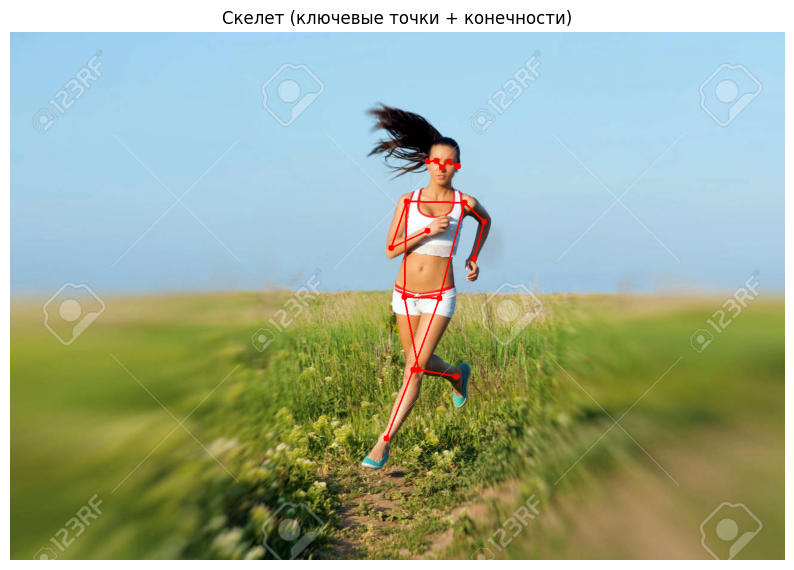

In [55]:
img_with_skeleton = draw_skeleton(
    img_bgr,
    keypoints_all,
    keypoints_scores,
    scores,
    limbs,
    keypoint_threshold=2,
    conf_threshold=0.9
)

# Отображаем результат
plt.figure(figsize=(10, 8))
plt.imshow(cv2.cvtColor(img_with_skeleton, cv2.COLOR_BGR2RGB))
plt.title("Скелет (ключевые точки + конечности)")
plt.axis('off')
plt.show()